<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Yeast/baseline_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Yeast/'

# fixed seed while the code is built and tested - the actual sweep
# will loop over multiple seeds per architecture
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(torch.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2.11.0+cpu


# Loading the split data and scaling and encoding

In [ ]:
# load the split we froze in modelling_prep - never regenerate it
train_df = pd.read_csv(data_dir + "split_train.csv")
val_df = pd.read_csv(data_dir + "split_val.csv")
test_df = pd.read_csv(data_dir + "split_test.csv")

feature_cols = [c for c in train_df.columns if c != "class"]

X_train, y_train = train_df[feature_cols], train_df["class"]
X_val, y_val = val_df[feature_cols], val_df["class"]
X_test, y_test = test_df[feature_cols], test_df["class"]

# scale - fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# encode labels by minority -> majority rank, fixed across the whole project
minority_to_majority_order = ['ERL', 'POX', 'VAC', 'EXC', 'ME1', 'ME2', 'ME3', 'MIT', 'NUC', 'CYT']
label_to_index = {label: i for i, label in enumerate(minority_to_majority_order)}
index_to_label = {i: label for label, i in label_to_index.items()}

y_train_idx = y_train.map(label_to_index).values
y_val_idx = y_val.map(label_to_index).values
y_test_idx = y_test.map(label_to_index).values

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(label_to_index)

Train: 929  Val: 233  Test: 291
{'ERL': 0, 'POX': 1, 'VAC': 2, 'EXC': 3, 'ME1': 4, 'ME2': 5, 'ME3': 6, 'MIT': 7, 'NUC': 8, 'CYT': 9}


# Convert to tensors

In [ ]:
# torch wants float32 for inputs and long (int64) for class indices
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_idx, dtype=torch.long)
y_val_t = torch.tensor(y_val_idx, dtype=torch.long)
y_test_t = torch.tensor(y_test_idx, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)

torch.Size([929, 8]) torch.Size([929])


# Defining a growable network

In [ ]:
class GrowableNet(nn.Module):
    """
    A single-hidden-layer network that can grow one hidden neuron or
    one output class at a time, keeping all previously learned weights.

    With hidden_dim = 0, there's no hidden layer at all - inputs map
    straight to outputs (this is what "start with the simplest
    architecture" means for stage 1).
    """
    def __init__(self, input_dim, output_dim, hidden_dim=0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        if hidden_dim == 0:
            self.fc_hidden = None
            self.fc_out = nn.Linear(input_dim, output_dim)
        else:
            self.fc_hidden = nn.Linear(input_dim, hidden_dim)
            self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if self.hidden_dim == 0:
            return self.fc_out(x)
        h = torch.tanh(self.fc_hidden(x))
        return self.fc_out(h)

    def add_hidden_neuron(self):
        """Grow the hidden layer by one neuron. Existing weights are copied
        across untouched, only the new neuron's weights are freshly
        initialised. Going from 0 to 1 hidden neuron is the one exception -
        there's no existing hidden layer to preserve, so this is a genuine
        architecture change, not a weight-preserving expansion."""
        if self.hidden_dim == 0:
            self.fc_hidden = nn.Linear(self.input_dim, 1)
            self.fc_out = nn.Linear(1, self.output_dim)
            self.hidden_dim = 1
            return

        old_dim = self.hidden_dim
        new_dim = old_dim + 1

        new_fc_hidden = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_hidden.weight[:old_dim] = self.fc_hidden.weight
            new_fc_hidden.bias[:old_dim] = self.fc_hidden.bias
        self.fc_hidden = new_fc_hidden

        new_fc_out = nn.Linear(new_dim, self.output_dim)
        with torch.no_grad():
            new_fc_out.weight[:, :old_dim] = self.fc_out.weight
            new_fc_out.bias[:] = self.fc_out.bias
        self.fc_out = new_fc_out

        self.hidden_dim = new_dim

    def add_output_class(self):
        """Grow the output layer by one class. All existing output
        neurons keep their learned weights - only the new class's
        output neuron is freshly initialised."""
        old_dim = self.output_dim
        new_dim = old_dim + 1
        in_features = self.hidden_dim if self.hidden_dim > 0 else self.input_dim

        new_fc_out = nn.Linear(in_features, new_dim)
        with torch.no_grad():
            new_fc_out.weight[:old_dim] = self.fc_out.weight
            new_fc_out.bias[:old_dim] = self.fc_out.bias
        self.fc_out = new_fc_out

        self.output_dim = new_dim


# quick sanity check - build a tiny net and grow it, just to see it doesn't error out
test_net = GrowableNet(input_dim=8, output_dim=2, hidden_dim=0)
print(test_net)
test_net.add_hidden_neuron()
print(test_net)
test_net.add_output_class()
print(test_net)

GrowableNet(
  (fc_out): Linear(in_features=8, out_features=2, bias=True)
)
GrowableNet(
  (fc_out): Linear(in_features=1, out_features=2, bias=True)
  (fc_hidden): Linear(in_features=8, out_features=1, bias=True)
)
GrowableNet(
  (fc_out): Linear(in_features=1, out_features=3, bias=True)
  (fc_hidden): Linear(in_features=8, out_features=1, bias=True)
)


# No skill baseline - reference point for a still high loss

In [ ]:
def no_skill_loss(y_indices, num_classes):
    """Cross-entropy loss of a classifier that just predicts each class's
    prior frequency - our reference point for what 'no better than
    guessing' looks like, given whichever classes are active right now."""
    counts = np.bincount(y_indices, minlength=num_classes)
    p = counts / counts.sum()
    p = p[p > 0]  # a class with 0 instances contributes nothing
    return -np.sum(p * np.log(p))

# Selecting which classes are active at a given stage

In [ ]:
def select_active(X_t, y_t, num_active_classes):
    """Our label encoding is ordered minority -> majority, so the
    'active classes' at any stage are always indices 0..num_active-1.
    This slices train/val/test down to just those classes."""
    mask = y_t < num_active_classes
    return X_t[mask], y_t[mask]

# The training loop: mini-batches, patience, restore best weights

In [ ]:
def train_until_stagnation(model, X_train, y_train, X_val, y_val,
                            max_epochs=500, patience=20, min_delta=0.001,
                            batch_size=16, lr=0.001):
    """Train with mini-batch Adam until validation loss stops improving
    for `patience` epochs, then restore the weights from whichever epoch
    had the best validation loss (not just wherever training happened
    to stop)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        running_loss = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(idx)

        train_loss = running_loss / n

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is None:
        raise RuntimeError("No best model state was recorded.")
    model.load_state_dict(best_state)
    return history, best_epoch, best_val_loss

# Function that will help define underfitting and overfitting

In [ ]:
def diagnose(history, best_epoch, no_skill, underfit_ratio=0.8, diverge_delta=0.01):
    train_loss = history["train_loss"][best_epoch]
    val_loss = history["val_loss"][best_epoch]

    # underfitting: even at its best point, barely beats guessing priors
    if train_loss > underfit_ratio * no_skill:
        return "underfitting", train_loss, val_loss

    # overfitting: the actual curve shape, not a snapshot -
    # did val loss climb back up after its best point, while
    # train loss kept dropping? that's the diverging-curves
    # picture from the slides
    final_train = history["train_loss"][-1]
    final_val = history["val_loss"][-1]
    val_rose = final_val > val_loss + diverge_delta
    train_kept_dropping = final_train < train_loss

    if val_rose and train_kept_dropping:
        return "overfitting", train_loss, val_loss

    return "satisfactory", train_loss, val_loss

# Test on all 10 classes, 0 hidden neurons (this is also the first point of the baseline sweep)

In [ ]:
torch.manual_seed(SEED)

X_tr, y_tr = select_active(X_train_t, y_train_t, num_active_classes=10)
X_v, y_v = select_active(X_val_t, y_val_t, num_active_classes=10)

net = GrowableNet(input_dim=8, output_dim=10, hidden_dim=0)
history, best_epoch, best_val_loss = train_until_stagnation(net, X_tr, y_tr, X_v, y_v)

baseline_no_skill = no_skill_loss(y_tr.numpy(), num_classes=10)
verdict, train_loss, val_loss = diagnose(history, best_epoch, baseline_no_skill)

print(f"Stopped after {len(history['train_loss'])} epochs, best epoch: {best_epoch}")
print(f"No-skill baseline loss: {baseline_no_skill:.4f}")
print(f"Train loss: {train_loss:.4f}  Val loss: {val_loss:.4f}")
print(f"Verdict: {verdict}")

Stopped after 154 epochs, best epoch: 133
No-skill baseline loss: 1.7337
Train loss: 1.0435  Val loss: 1.1788
Verdict: satisfactory


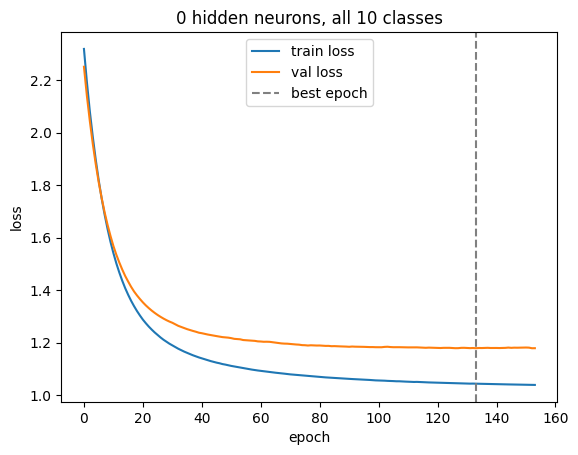

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label="best epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("0 hidden neurons, all 10 classes")
plt.show()

# Accuracy and F1 reporting not for the stopping decision

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, X, y_true_idx):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1).numpy()
    y_true = y_true_idx.numpy()
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    return acc, macro_f1

# The sweep: hidden sizes 0 to 30, 5 seeds each

In [ ]:
hidden_sizes = list(range(0, 31))
n_seeds = 5

baseline_no_skill = no_skill_loss(y_train_t.numpy(), num_classes=10)  # same for every run here - all 10 classes, same train set

sweep_results = []

for h in hidden_sizes:
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        net = GrowableNet(input_dim=8, output_dim=10, hidden_dim=h)
        history, best_epoch, best_val_loss = train_until_stagnation(
            net, X_train_t, y_train_t, X_val_t, y_val_t
        )
        verdict, train_loss, val_loss = diagnose(history, best_epoch, baseline_no_skill)
        val_acc, val_f1 = evaluate(net, X_val_t, y_val_t)

        sweep_results.append({
            "hidden_size": h, "seed": seed, "best_epoch": best_epoch,
            "train_loss": train_loss, "val_loss": val_loss,
            "val_acc": val_acc, "val_macro_f1": val_f1, "verdict": verdict,
        })

sweep_df = pd.DataFrame(sweep_results)
sweep_df.head()

,hidden_size,seed,best_epoch,train_loss,val_loss,val_acc,val_macro_f1,verdict
0,0,0,112,1.050151,1.176206,0.566524,0.572610,satisfactory
1,0,1,140,1.040866,1.176724,0.562232,0.524863,satisfactory
2,0,2,118,1.049153,1.178894,0.570815,0.536054,satisfactory
3,0,3,153,1.039723,1.176900,0.575107,0.543863,satisfactory
4,0,4,135,1.044129,1.178725,0.575107,0.575251,satisfactory


# Aggregate across seeds, so picking based on averages, not a lucky/unlucky run

In [ ]:
summary = sweep_df.groupby("hidden_size").agg(
    val_loss_mean=("val_loss", "mean"),
    val_loss_std=("val_loss", "std"),
    val_acc_mean=("val_acc", "mean"),
    val_macro_f1_mean=("val_macro_f1", "mean"),
    pct_overfit=("verdict", lambda v: (v == "overfitting").mean()),
    pct_underfit=("verdict", lambda v: (v == "underfitting").mean()),
).reset_index()
summary

,hidden_size,val_loss_mean,val_loss_std,val_acc_mean,val_macro_f1_mean,pct_overfit,pct_underfit
0,0,1.177490,0.001233,0.569957,0.550528,0.0,0.0
1,1,1.472567,0.016404,0.379399,0.147386,0.0,1.0
2,2,1.327570,0.019419,0.456652,0.254689,0.0,0.0
3,3,1.249155,0.032338,0.523605,0.367093,0.0,0.0
4,4,1.212553,0.026004,0.539914,0.422094,0.0,0.0
5,5,1.182274,0.012256,0.572532,0.504881,0.0,0.0
6,6,1.188728,0.004970,0.569957,0.512727,0.0,0.0
7,7,1.183946,0.015751,0.567382,0.501781,0.0,0.0
8,8,1.175884,0.021969,0.569099,0.570048,0.0,0.0
9,9,1.165322,0.020885,0.578541,0.554531,0.0,0.0


In [ ]:
def add_underfitting_flags(summary, threshold=0.02):
    """
    Retrospective check across the (independently-trained) sweep architectures:
    was there a meaningfully better *larger* architecture further along the sweep?
    Valid here specifically because every architecture is already fully trained -
    this is a description of what happened, not a live growth decision.
    """
    val_by_size = summary.set_index("hidden_size")["val_loss_mean"]
    running_min = np.inf
    best_forward = {}
    for h in sorted(summary["hidden_size"], reverse=True):
        best_forward[h] = running_min
        running_min = min(running_min, val_by_size[h])

    summary = summary.copy()
    summary["best_forward_val_loss"] = summary["hidden_size"].map(best_forward)
    summary["underfitting"] = (summary["val_loss_mean"] - summary["best_forward_val_loss"]) > threshold
    return summary

summary = add_underfitting_flags(summary)
summary

,hidden_size,val_loss_mean,val_loss_std,val_acc_mean,val_macro_f1_mean,pct_overfit,pct_underfit,best_forward_val_loss,underfitting
0,0,1.177490,0.001233,0.569957,0.550528,0.0,0.0,1.151487,True
1,1,1.472567,0.016404,0.379399,0.147386,0.0,1.0,1.151487,True
2,2,1.327570,0.019419,0.456652,0.254689,0.0,0.0,1.151487,True
3,3,1.249155,0.032338,0.523605,0.367093,0.0,0.0,1.151487,True
4,4,1.212553,0.026004,0.539914,0.422094,0.0,0.0,1.151487,True
5,5,1.182274,0.012256,0.572532,0.504881,0.0,0.0,1.151487,True
6,6,1.188728,0.004970,0.569957,0.512727,0.0,0.0,1.151487,True
7,7,1.183946,0.015751,0.567382,0.501781,0.0,0.0,1.151487,True
8,8,1.175884,0.021969,0.569099,0.570048,0.0,0.0,1.151487,True
9,9,1.165322,0.020885,0.578541,0.554531,0.0,0.0,1.151487,False


# One standard-error rule - simplest architecture within noise of the best

In [ ]:
best_val_loss_mean = summary["val_loss_mean"].min()
best_row_raw = summary.loc[summary["val_loss_mean"].idxmin()]
se = best_row_raw["val_loss_std"] / np.sqrt(n_seeds)

within_one_se = summary[summary["val_loss_mean"] <= best_val_loss_mean + se]
print("Architectures statistically tied with the best (within 1 SE):")
print(within_one_se[["hidden_size", "val_loss_mean", "val_macro_f1_mean"]])

selected = within_one_se.loc[within_one_se["val_macro_f1_mean"].idxmax()]
print(f"\nSelected baseline architecture: {int(selected['hidden_size'])} hidden neurons")
print(selected)

Architectures statistically tied with the best (within 1 SE):
    hidden_size  val_loss_mean  val_macro_f1_mean
25           25       1.153008           0.569640
26           26       1.151834           0.552788
27           27       1.151487           0.559970
29           29       1.153902           0.548024

Selected baseline architecture: 25 hidden neurons
hidden_size                    25
val_loss_mean            1.153008
val_loss_std             0.012982
val_acc_mean             0.577682
val_macro_f1_mean         0.56964
pct_overfit                   0.2
pct_underfit                  0.0
best_forward_val_loss    1.151487
underfitting                False
Name: 25, dtype: object


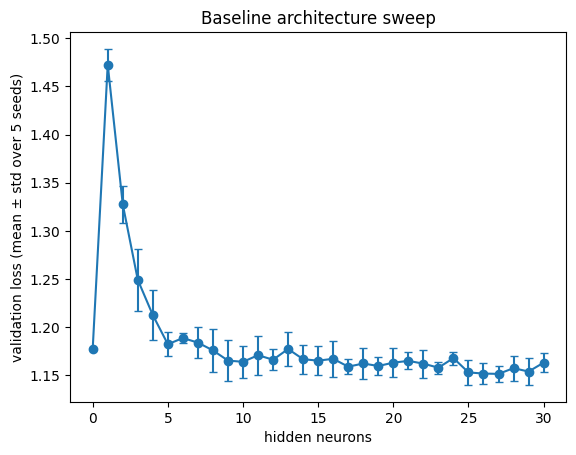

In [ ]:
plt.errorbar(summary["hidden_size"], summary["val_loss_mean"], yerr=summary["val_loss_std"], marker="o", capsize=3)
plt.xlabel("hidden neurons")
plt.ylabel("validation loss (mean ± std over 5 seeds)")
plt.title("Baseline architecture sweep")
plt.savefig("yeast_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

The spike at h=1 (val_loss jumps above even h=0) is expected here, not a bug - unlike the incremental notebook, baseline trains every hidden size completely from scratch, so a single tanh neuron creates a genuine bottleneck that's harder
for Adam to optimise than either no hidden layer (h=0) or a few more neurons giving it room to work. This is unrelated to the 0->1 weight-discarding bug from the incremental methodology - there's no weight-preserving growth step here for that bug to occur in. The curve recovers by h=2-3 and flattens out
from h~9 onward, which is what the one-SE rule is selecting within.

# Graph for report

In [ ]:
# check whether any architecture in the sweep was flagged as overfitting
overfit_runs = sweep_df[sweep_df["verdict"] == "overfitting"]
print(f"{len(overfit_runs)} of {len(sweep_df)} sweep runs flagged as overfitting")
print(overfit_runs[["hidden_size", "seed", "val_loss"]])

5 of 155 sweep runs flagged as overfitting
     hidden_size  seed  val_loss
113           22     3  1.139096
118           23     3  1.155774
120           24     0  1.160347
127           25     2  1.139026
134           26     4  1.141255


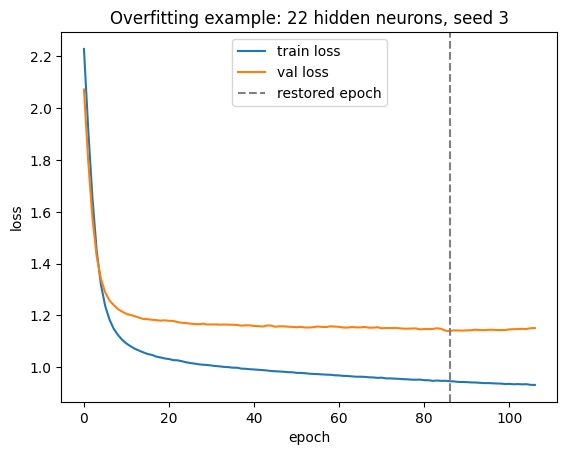

train at best epoch = 0.9459, val at best epoch = 1.1391, train final = 0.9314, val final = 1.1512


In [ ]:
input_dim = X_train_t.shape[1]
output_dim = int(y_train_t.max().item()) + 1

h_example, seed_example = overfit_runs.iloc[0][["hidden_size", "seed"]]
h_example, seed_example = int(h_example), int(seed_example)

torch.manual_seed(seed_example)
net_example = GrowableNet(input_dim=input_dim, output_dim=output_dim, hidden_dim=h_example)
history_example, best_epoch_example, _ = train_until_stagnation(
    net_example, X_train_t, y_train_t, X_val_t, y_val_t
)

plt.plot(history_example["train_loss"], label="train loss")
plt.plot(history_example["val_loss"], label="val loss")
plt.axvline(best_epoch_example, color="gray", linestyle="--", label="restored epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Overfitting example: {h_example} hidden neurons, seed {seed_example}")
plt.legend()
plt.savefig("yeast_overfitting_example.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"train at best epoch = {history_example['train_loss'][best_epoch_example]:.4f}, "
      f"val at best epoch = {history_example['val_loss'][best_epoch_example]:.4f}, "
      f"train final = {history_example['train_loss'][-1]:.4f}, "
      f"val final = {history_example['val_loss'][-1]:.4f}")

# Test evaluation with the selected architecture:

In [ ]:
BASELINE_HIDDEN_SIZE = 25
baseline_test_results = []

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=8, output_dim=10, hidden_dim=BASELINE_HIDDEN_SIZE)
    history, best_epoch, best_val_loss = train_until_stagnation(
        net, X_train_t, y_train_t, X_val_t, y_val_t
    )
    test_acc, test_f1 = evaluate(net, X_test_t, y_test_t)

    baseline_test_results.append({
        "seed": seed, "hidden_size": BASELINE_HIDDEN_SIZE,
        "best_epoch": best_epoch + 1,
        "val_loss": best_val_loss,
        "test_acc": test_acc, "test_macro_f1": test_f1,
    })

baseline_test_df = pd.DataFrame(baseline_test_results)
baseline_test_df

,seed,hidden_size,best_epoch,val_loss,test_acc,test_macro_f1
0,0,25,78,1.163243,0.621993,0.599732
1,1,25,34,1.162480,0.621993,0.603924
2,2,25,52,1.139026,0.597938,0.582945
3,3,25,65,1.138575,0.594502,0.558702
4,4,25,40,1.161716,0.632302,0.580965


# Confusion matrices per seed

In [ ]:
from sklearn.metrics import confusion_matrix

class_names_ordered = minority_to_majority_order  # already readable strings, no CLASS_NAMES lookup needed

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=8, output_dim=10, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)

    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    cm = confusion_matrix(y_test_t.numpy(), preds, labels=range(10))

    print(f"\n--- seed {seed} ---")
    print(pd.DataFrame(cm, index=class_names_ordered, columns=class_names_ordered))


--- seed 0 ---
     ERL  POX  VAC  EXC  ME1  ME2  ME3  MIT  NUC  CYT
ERL    1    0    0    0    0    0    0    0    0    0
POX    0    2    0    0    0    0    0    0    0    2
VAC    0    0    0    1    0    0    2    0    1    2
EXC    0    0    0    3    2    0    0    1    0    1
ME1    0    0    0    1    7    1    0    0    0    0
ME2    0    0    0    0    2    5    0    1    1    1
ME3    0    0    0    0    0    0   25    1    3    3
MIT    0    0    0    0    1    2    2   31    3   10
NUC    0    0    0    0    0    0    2    4   54   25
CYT    0    0    0    1    0    0    0    7   27   53

--- seed 1 ---
     ERL  POX  VAC  EXC  ME1  ME2  ME3  MIT  NUC  CYT
ERL    1    0    0    0    0    0    0    0    0    0
POX    0    2    0    0    0    0    0    0    0    2
VAC    0    0    0    1    0    0    2    0    1    2
EXC    0    0    0    3    2    0    0    1    0    1
ME1    0    0    0    0    8    1    0    0    0    0
ME2    0    0    0    1    2    5    0    0    1  

ERL is classified perfectly in every seed, but with only 1 test instance this isn't statistically meaningful. The more notable finding is VAC (30
instances, not the rarest class) - it has 0% recall in every single seed, with all 6 test instances misclassified across EXC/ME3/NUC/CYT. NUC and CYT,the two majority classes, are heavily confused with each other in both directions, and MIT bleeds substantially into both - consistent with the heavy feature overlap seen in the mit/nuc box plots during EDA. ME1 and ME3 are classified reliably, matching alm's visible separating trend by class.
Overall test accuracy (60%) and macro F1 (0.58) are well below Glass's baseline, reflecting Yeast's larger number of classes and more overlapping features.

In [ ]:
sweep_df.to_csv(data_dir + "baseline_sweep_results.csv", index=False)
summary.to_csv(data_dir + "baseline_sweep_summary.csv", index=False)
baseline_test_df.to_csv(data_dir + "baseline_test_results.csv", index=False)
print("Saved baseline sweep, summary, and final test results to Drive.")

Saved baseline sweep, summary, and final test results to Drive.


# per-instance predictions for the incremental models (needed for the paired test)


In [ ]:
criterion_ni = nn.CrossEntropyLoss(reduction="none")
baseline_instance_records = []

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=8, output_dim=10, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)

    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        per_instance_loss = criterion_ni(logits, y_test_t).numpy()
        preds = logits.argmax(dim=1).numpy()

    for i in range(len(y_test_t)):
        baseline_instance_records.append({
            "seed": seed, "instance": i,
            "loss": per_instance_loss[i],
            "correct": int(preds[i] == y_test_t[i].item()),
        })

baseline_instance_df = pd.DataFrame(baseline_instance_records)
baseline_instance_df.to_csv(data_dir + "baseline_test_instance_predictions.csv", index=False)
print("Saved per-instance baseline test predictions.")

Saved per-instance baseline test predictions.


In [ ]:
from sklearn.metrics import recall_score

baseline_recall_runs = []
for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=8, output_dim=10, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    baseline_recall_runs.append(recall_score(y_test_t.numpy(), preds, labels=range(10), average=None))

baseline_recall = np.mean(baseline_recall_runs, axis=0)
pd.DataFrame({"class": class_names_ordered, "baseline_recall": baseline_recall}).to_csv(
    data_dir + "baseline_per_class_recall.csv", index=False
)
print("Saved baseline per-class recall.")

Saved baseline per-class recall.
